#Analyse de la base de données ventes 

In [2]:
#Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#importer la base de données
df = pd.read_csv(r"C:\Users\Princesse\Downloads\Nouveau_départ\Entreprises\1\ventes.csv", encoding="latin1")

In [8]:
#Voir les premières lignes de la base de données
df.head()

,ORDERNUMBER,quantite_commandee,prix_unitaire,numero_ligne,montant_vente,date_commande,statut,trimestre,mois,annee,...,adresse_ligne1,adresse_ligne2,ville,etat_province,code_postal,pays,territoire,nom_contact,prenom_contact,taille_transaction
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
#la liste des variables de la base de données
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [6]:
#renommer les variables de la base de données
df= df.rename(columns={
    "ORDERNUMER": "numero_commande",
    "QUANTITYORDERED": "quantite_commandee",
    "PRICEEACH": "prix_unitaire",
    "ORDERLINENUMBER": "numero_ligne",
    "SALES": "montant_vente",
    "ORDERDATE": "date_commande",
    "STATUS": "statut",
    "QTR_ID": "trimestre", 
    "MONTH_ID": "mois",
    "YEAR_ID": "annee", 
    "PRODUCTLINE": "ligne_produit",
    "MSRP": "prix_catalogue",
    "PRODUCTCODE": "code_produit",
    "CUSTOMERNAME": "nom_client",
    "PHONE": "telephone", 
    "ADDRESSLINE1": "adresse_ligne1",
    "ADDRESSLINE2": "adresse_ligne2",
    "CITY": "ville",
    "STATE": "etat_province",
    "POSTALCODE": "code_postal",
    "COUNTRY": "pays",
    "TERRITORY": "territoire",
    "CONTACTLASTNAME": "nom_contact",
    "CONTACTFIRSTNAME": "prenom_contact",
    "DEALSIZE": "taille_transaction",})

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [7]:
df.columns

Index(['ORDERNUMBER', 'quantite_commandee', 'prix_unitaire', 'numero_ligne',
       'montant_vente', 'date_commande', 'statut', 'trimestre', 'mois',
       'annee', 'ligne_produit', 'prix_catalogue', 'code_produit',
       'nom_client', 'telephone', 'adresse_ligne1', 'adresse_ligne2', 'ville',
       'etat_province', 'code_postal', 'pays', 'territoire', 'nom_contact',
       'prenom_contact', 'taille_transaction'],
      dtype='object')

In [12]:
df.describe()


,ORDERNUMBER,quantite_commandee,prix_unitaire,numero_ligne,montant_vente,prix_catalogue
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,214.000000


In [10]:
# Conversion des variables en catégorielle
df['trimestre'] = df['trimestre'].astype('category')
df['mois']      = df['mois'].astype('category')
df['annee']     = df['annee'].astype('category')

# Vérification
print(df.dtypes)

ORDERNUMBER              int64
quantite_commandee       int64
prix_unitaire          float64
numero_ligne             int64
montant_vente          float64
date_commande           object
statut                  object
trimestre             category
mois                  category
annee                 category
ligne_produit           object
prix_catalogue           int64
code_produit            object
nom_client              object
telephone               object
adresse_ligne1          object
adresse_ligne2          object
ville                   object
etat_province           object
code_postal             object
pays                    object
territoire              object
nom_contact             object
prenom_contact          object
taille_transaction      object
dtype: object


In [14]:
df['ORDERNUMBER'] = df['ORDERNUMBER'].astype(str)
df['numero_ligne']    = df['numero_ligne'].astype(str)

In [16]:
df.dtypes

ORDERNUMBER             object
quantite_commandee       int64
prix_unitaire          float64
numero_ligne            object
montant_vente          float64
date_commande           object
statut                  object
trimestre             category
mois                  category
annee                 category
ligne_produit           object
prix_catalogue           int64
code_produit            object
nom_client              object
telephone               object
adresse_ligne1          object
adresse_ligne2          object
ville                   object
etat_province           object
code_postal             object
pays                    object
territoire              object
nom_contact             object
prenom_contact          object
taille_transaction      object
dtype: object

In [17]:
quantitative_cols = df.select_dtypes(include=['int64', 'float64']).columns
qualitative_cols = df.select_dtypes(include=['object', 'category']).columns

In [18]:
print(df[quantitative_cols].describe())

       quantite_commandee  prix_unitaire  montant_vente  prix_catalogue
count         2823.000000    2823.000000    2823.000000     2823.000000
mean            35.092809      83.658544    3553.889072      100.715551
std              9.741443      20.174277    1841.865106       40.187912
min              6.000000      26.880000     482.130000       33.000000
25%             27.000000      68.860000    2203.430000       68.000000
50%             35.000000      95.700000    3184.800000       99.000000
75%             43.000000     100.000000    4508.000000      124.000000
max             97.000000     100.000000   14082.800000      214.000000


In [19]:
from scipy import stats          # Tests statistiques
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
sns.set_palette("Set2")

In [21]:
# ============================================================
# STATISTIQUES DESCRIPTIVES GLOBALES
# ============================================================

print("="*55)
print("STATISTIQUES GÉNÉRALES SUR LES VENTES")
print("="*55)

print(f"\n Total de commandes     : {df['ORDERNUMBER'].nunique()}")
print(f" Total de lignes        : {len(df)}")
print(f" Période couverte       : {df['annee'].unique().tolist()}")
print(f" Pays représentés       : {df['pays'].unique()}")
print(f" Lignes de produits     : {df['ligne_produit'].unique()}")

print("\n--- Ventes (montant_vente) ---")
print(df['montant_vente'].describe().round(2))

print("\n--- Quantités commandées ---")
print(df['quantite_commandee'].describe().round(2))

STATISTIQUES GÉNÉRALES SUR LES VENTES

 Total de commandes     : 307
 Total de lignes        : 2823
 Période couverte       : [2003, 2004, 2005]
 Pays représentés       : ['USA' 'France' 'Norway' 'Australia' 'Finland' 'Austria' 'UK' 'Spain'
 'Sweden' 'Singapore' 'Canada' 'Japan' 'Italy' 'Denmark' 'Belgium'
 'Philippines' 'Germany' 'Switzerland' 'Ireland']
 Lignes de produits     : ['Motorcycles' 'Classic Cars' 'Trucks and Buses' 'Vintage Cars' 'Planes'
 'Ships' 'Trains']

--- Ventes (montant_vente) ---
count     2823.00
mean      3553.89
std       1841.87
min        482.13
25%       2203.43
50%       3184.80
75%       4508.00
max      14082.80
Name: montant_vente, dtype: float64

--- Quantités commandées ---
count    2823.00
mean       35.09
std         9.74
min         6.00
25%        27.00
50%        35.00
75%        43.00
max        97.00
Name: quantite_commandee, dtype: float64


       nb_transactions  total_ventes  moyenne  mediane  ecart_type     min  \
annee                                                                        
2003              1000    3516979.54  3516.98  3210.10     1763.68  710.20   
2004              1345    4724162.60  3512.39  3141.57     1775.28  577.60   
2005               478    1791486.71  3747.88  3316.82     2151.80  482.13   

           max  
annee           
2003   11279.2  
2004   12536.5  
2005   14082.8  


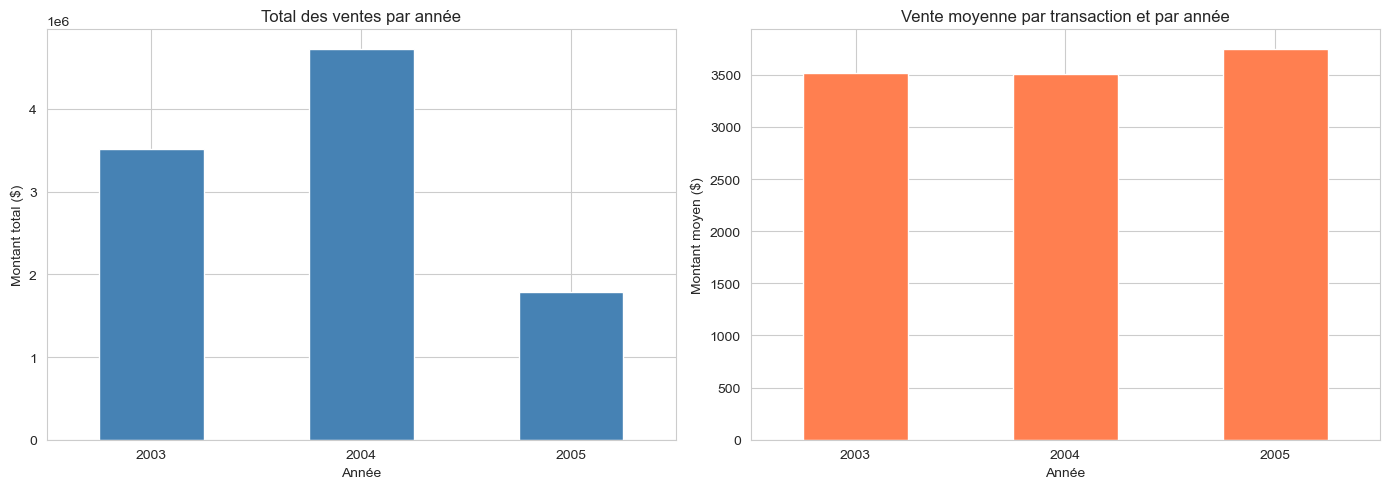

In [22]:
# ============================================================
# ANALYSE PAR ANNÉE
# ============================================================

stats_annee = df.groupby('annee')['montant_vente'].agg(
    nb_transactions = 'count',
    total_ventes    = 'sum',
    moyenne         = 'mean',
    mediane         = 'median',
    ecart_type      = 'std',
    min             = 'min',
    max             = 'max'
).round(2)

print(stats_annee)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total des ventes par année
stats_annee['total_ventes'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Total des ventes par année")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Montant total ($)")
axes[0].tick_params(axis='x', rotation=0)

# Moyenne des ventes par année
stats_annee['moyenne'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Vente moyenne par transaction et par année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Montant moyen ($)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

           nb_transactions  total_ventes  moyenne  mediane  ecart_type
trimestre                                                             
1                      665    2350817.73  3535.06  3222.00     1735.27
2                      561    2048120.30  3650.84  3138.34     2113.19
3                      503    1758910.81  3496.84  3098.70     1782.24
4                     1094    3874780.01  3541.85  3206.86     1782.18


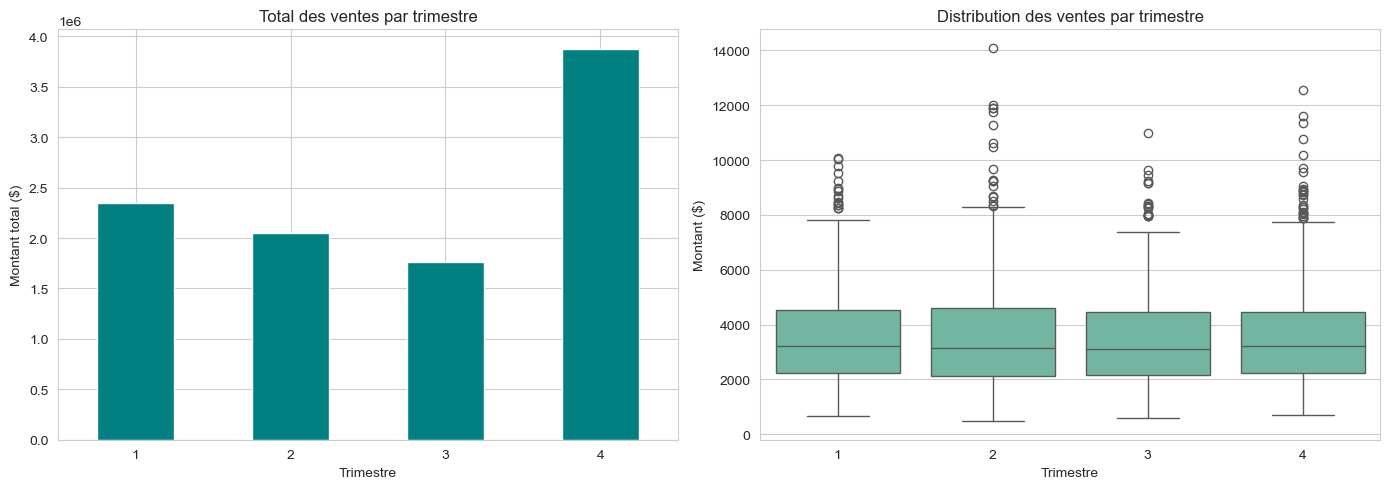

In [23]:
# ============================================================
# ANALYSE PAR TRIMESTRE
# ============================================================

stats_trim = df.groupby('trimestre')['montant_vente'].agg(
    nb_transactions = 'count',
    total_ventes    = 'sum',
    moyenne         = 'mean',
    mediane         = 'median',
    ecart_type      = 'std'
).round(2)

print(stats_trim)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats_trim['total_ventes'].plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title("Total des ventes par trimestre")
axes[0].set_xlabel("Trimestre")
axes[0].set_ylabel("Montant total ($)")
axes[0].tick_params(axis='x', rotation=0)

# Boxplot des montants par trimestre
sns.boxplot(x='trimestre', y='montant_vente', data=df, ax=axes[1])
axes[1].set_title("Distribution des ventes par trimestre")
axes[1].set_xlabel("Trimestre")
axes[1].set_ylabel("Montant ($)")

plt.tight_layout()
plt.show()

      nb_transactions  total_ventes  moyenne  mediane
mois                                                 
1                 229     785874.44  3431.77  3160.25
2                 224     810441.90  3618.04  3244.32
3                 212     754501.39  3558.97  3183.16
4                 178     669390.96  3760.62  3057.81
5                 252     923972.56  3666.56  3166.56
6                 131     454756.78  3471.43  3248.70
7                 141     514875.97  3651.60  3204.00
8                 191     659310.57  3451.89  3131.94
9                 171     584724.27  3419.44  2866.26
10                317    1121215.22  3536.96  3286.49
11                597    2118885.67  3549.22  3167.36
12                180     634679.12  3526.00  3210.10


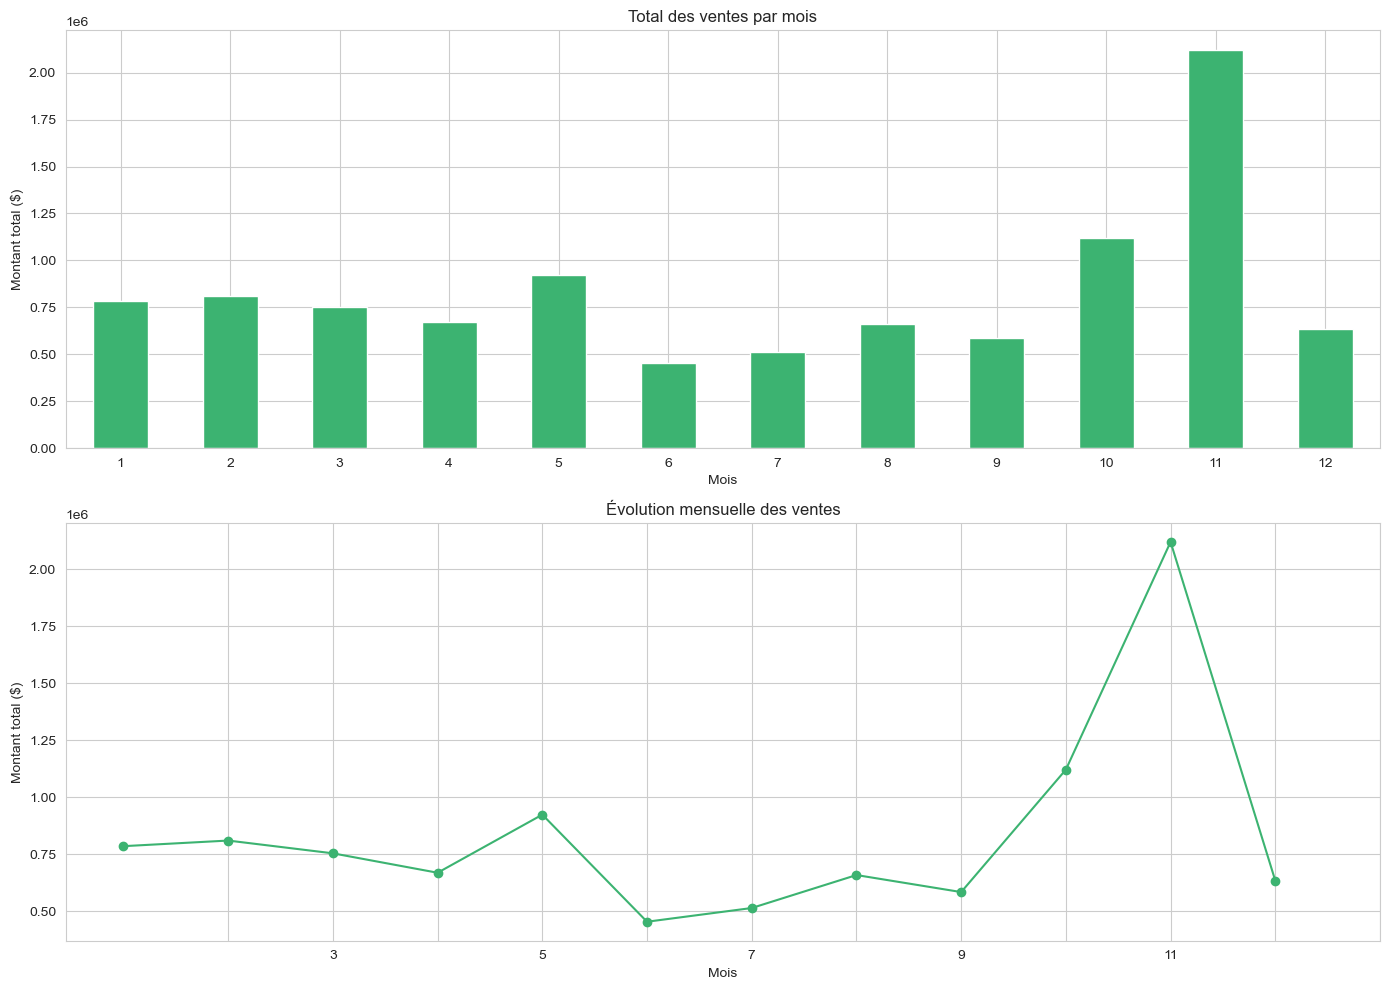

In [24]:
# ============================================================
# ANALYSE PAR MOIS
# ============================================================

stats_mois = df.groupby('mois')['montant_vente'].agg(
    nb_transactions = 'count',
    total_ventes    = 'sum',
    moyenne         = 'mean',
    mediane         = 'median'
).round(2)

print(stats_mois)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Total des ventes par mois
stats_mois['total_ventes'].plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title("Total des ventes par mois")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("Montant total ($)")
axes[0].tick_params(axis='x', rotation=0)

# Courbe d'évolution mensuelle
stats_mois['total_ventes'].plot(kind='line', ax=axes[1], marker='o', color='mediumseagreen')
axes[1].set_title("Évolution mensuelle des ventes")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Montant total ($)")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [31]:
plt.figure()
# ton graphique
plt.savefig("grap1.png")

plt.figure()
# autre graphique
plt.savefig("grap2.png")

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

=== TOP PAYS ===
           nb_transactions  total_ventes  moyenne  mediane
pays                                                      
USA                   1004    3627982.83  3613.53  3236.06
Spain                  342    1215686.92  3554.64  3213.80
France                 314    1110916.52  3537.95  3154.30
Australia              185     630623.10  3408.77  3070.40
UK                     144     478880.46  3325.56  3122.47
Italy                  113     374674.31  3315.70  2915.66
Finland                 92     329581.91  3582.41  3247.83
Norway                  85     307463.70  3617.22  3394.98
Singapore               79     288488.41  3651.75  3127.88
Denmark                 63     245637.15  3899.00  3193.52

=== PAR TERRITOIRE ===
            nb_transactions  total_ventes  moyenne
territoire                                        
EMEA                   1407    4979272.41  3538.93
APAC                    221     746121.83  3376.12
Japan                   121     455173.22  3761

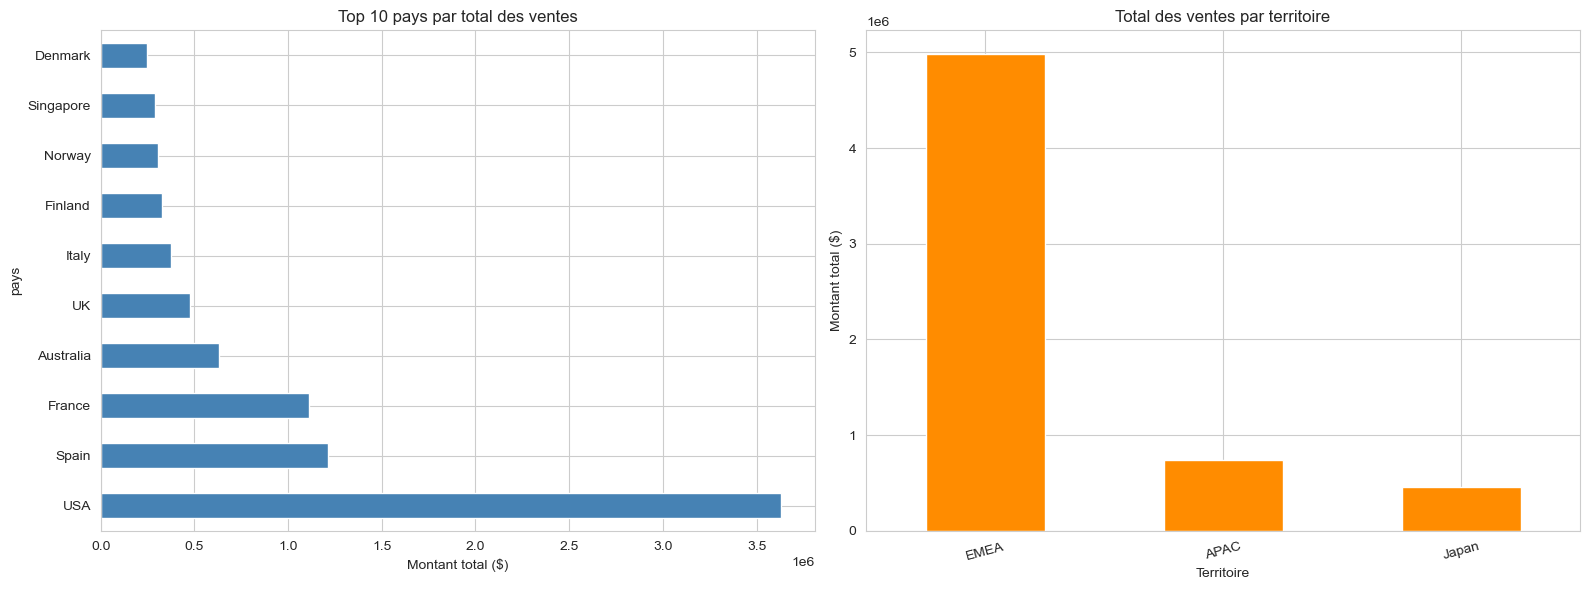

In [25]:
# ============================================================
# ANALYSE PAR PAYS ET TERRITOIRE
# ============================================================

# --- Par pays ---
stats_pays = df.groupby('pays')['montant_vente'].agg(
    nb_transactions = 'count',
    total_ventes    = 'sum',
    moyenne         = 'mean',
    mediane         = 'median'
).sort_values('total_ventes', ascending=False).round(2)

print("=== TOP PAYS ===")
print(stats_pays.head(10))

# --- Par territoire ---
stats_territoire = df.groupby('territoire')['montant_vente'].agg(
    nb_transactions = 'count',
    total_ventes    = 'sum',
    moyenne         = 'mean'
).sort_values('total_ventes', ascending=False).round(2)

print("\n=== PAR TERRITOIRE ===")
print(stats_territoire)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 pays
stats_pays['total_ventes'].head(10).plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Top 10 pays par total des ventes")
axes[0].set_xlabel("Montant total ($)")

# Par territoire
stats_territoire['total_ventes'].plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title("Total des ventes par territoire")
axes[1].set_xlabel("Territoire")
axes[1].set_ylabel("Montant total ($)")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [33]:
plt.figure()
# ton graphique
plt.savefig("grap.png")

plt.figure()
# autre graphique
plt.savefig("gra.png")

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

=== PAR LIGNE DE PRODUIT ===
                  nb_transactions  total_ventes  moyenne  mediane  ecart_type
ligne_produit                                                                
Classic Cars                  967    3919615.66  4053.38  3761.37     2050.69
Vintage Cars                  607    1903150.84  3135.34  2795.27     1787.57
Motorcycles                   331    1166388.34  3523.83  3127.82     1837.29
Trucks and Buses              301    1127789.84  3746.81  3449.40     1671.72
Planes                        306     975003.57  3186.29  2841.80     1519.54
Ships                         234     714437.13  3053.15  2884.92     1073.71
Trains                         77     226243.47  2938.23  2445.60     1456.60

=== PAR TAILLE DE TRANSACTION ===
                    nb_transactions  total_ventes  moyenne
taille_transaction                                        
Large                           157    1302119.26  8293.75
Medium                         1384    6087432.24  4398.4

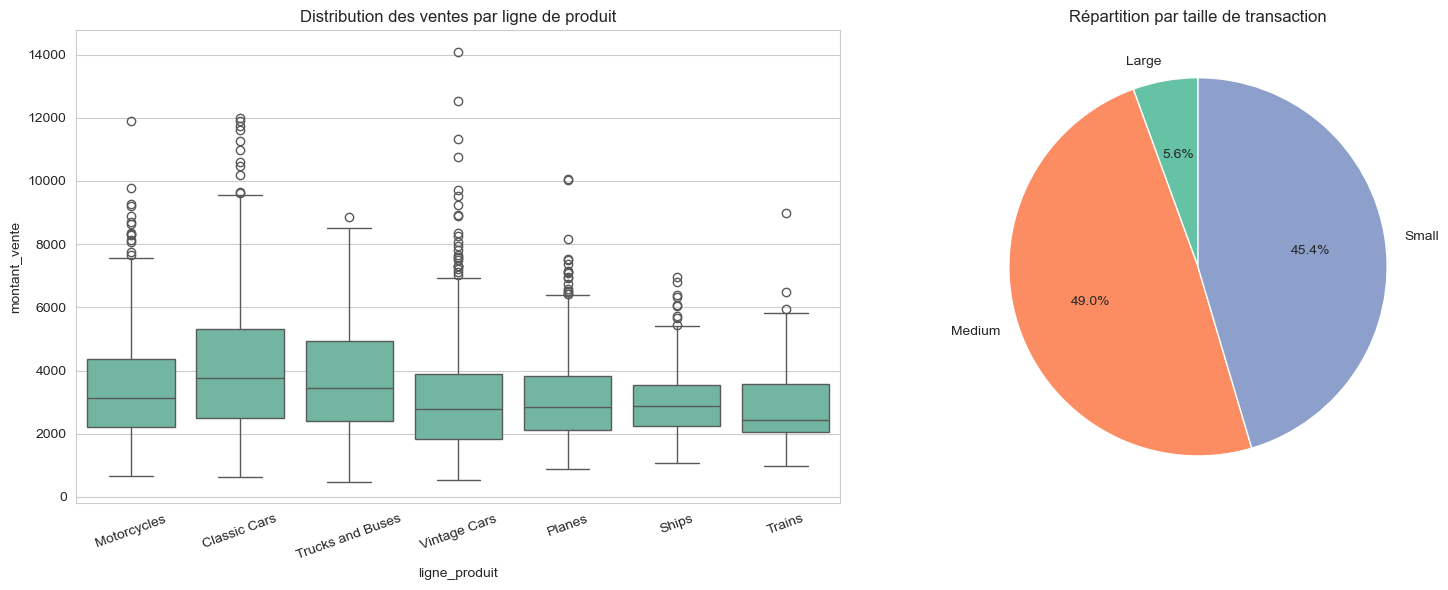

In [29]:
# ============================================================
# ANALYSE PAR LIGNE DE PRODUIT ET TAILLE DE TRANSACTION
# ============================================================

# --- Par ligne de produit ---
stats_produit = df.groupby('ligne_produit')['montant_vente'].agg(
    nb_transactions = 'count',
    total_ventes    = 'sum',
    moyenne         = 'mean',
    mediane         = 'median',
    ecart_type      = 'std'
).sort_values('total_ventes', ascending=False).round(2)

print("=== PAR LIGNE DE PRODUIT ===")
print(stats_produit)

# --- Par taille de transaction ---
stats_taille = df.groupby('taille_transaction')['montant_vente'].agg(
    nb_transactions = 'count',
    total_ventes    = 'sum',
    moyenne         = 'mean'
).round(2)

print("\n=== PAR TAILLE DE TRANSACTION ===")
print(stats_taille)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='ligne_produit', y='montant_vente', data=df, ax=axes[0])
axes[0].set_title("Distribution des ventes par ligne de produit")
axes[0].tick_params(axis='x', rotation=20)

# Camembert des tailles de transaction
stats_taille['nb_transactions'].plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title("Répartition par taille de transaction")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [30]:
plt.figure()
# ton graphique
plt.savefig("graph1.png")

plt.figure()
# autre graphique
plt.savefig("graph2.png")

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [34]:
# ============================================================
# TABLEAU DE CONTINGENCE : PRODUIT × ANNÉE
# Nombre de ventes par catégorie de produit et par année
# ============================================================

# -- Tableau des effectifs (nombre de ventes) --
contingence_annee = pd.crosstab(
    index   = df['ligne_produit'],   # lignes = catégories de produits
    columns = df['annee'],            # colonnes = années
    margins = True,                   # ajoute une ligne/colonne Total
    margins_name = "TOTAL"
)

print("=== EFFECTIFS : Produit × Année ===")
print(contingence_annee)

# -- Tableau des fréquences en % (par rapport au total général) --
contingence_annee_pct = pd.crosstab(
    index   = df['ligne_produit'],
    columns = df['annee'],
    normalize = True                  # normalize=True → proportions sur total général
).round(4) * 100                      # convertir en pourcentage

print("\n=== FRÉQUENCES (%) : Produit × Année ===")
print(contingence_annee_pct.round(2))

# -- Fréquences par ligne (% dans chaque produit) --
contingence_annee_ligne = pd.crosstab(
    index   = df['ligne_produit'],
    columns = df['annee'],
    normalize = 'index'               # normalize='index' → % sur chaque ligne
).round(4) * 100

print("\n=== FRÉQUENCES PAR LIGNE DE PRODUIT (%) ===")
print(contingence_annee_ligne.round(2))

# -- Fréquences par colonne (% dans chaque année) --
contingence_annee_col = pd.crosstab(
    index   = df['ligne_produit'],
    columns = df['annee'],
    normalize = 'columns'             # normalize='columns' → % sur chaque colonne
).round(4) * 100

print("\n=== FRÉQUENCES PAR ANNÉE (%) ===")
print(contingence_annee_col.round(2))

=== EFFECTIFS : Produit × Année ===
annee             2003  2004  2005  TOTAL
ligne_produit                            
Classic Cars       366   442   159    967
Motorcycles        109   164    58    331
Planes              85   161    60    306
Ships               81   115    38    234
Trains              28    37    12     77
Trucks and Buses   110   142    49    301
Vintage Cars       221   284   102    607
TOTAL             1000  1345   478   2823

=== FRÉQUENCES (%) : Produit × Année ===
annee              2003   2004  2005
ligne_produit                       
Classic Cars      12.96  15.66  5.63
Motorcycles        3.86   5.81  2.05
Planes             3.01   5.70  2.13
Ships              2.87   4.07  1.35
Trains             0.99   1.31  0.43
Trucks and Buses   3.90   5.03  1.74
Vintage Cars       7.83  10.06  3.61

=== FRÉQUENCES PAR LIGNE DE PRODUIT (%) ===
annee              2003   2004   2005
ligne_produit                        
Classic Cars      37.85  45.71  16.44
Motorcycle

In [38]:
# ============================================================
# TABLEAU DE CONTINGENCE : PRODUIT × TRIMESTRE
# ============================================================

# -- Effectifs --
contingence_trim = pd.crosstab(
    index        = df['ligne_produit'],
    columns      = df['trimestre'],
    margins      = True,
    margins_name = "TOTAL"
)

# Renommer les colonnes pour plus de clarté
contingence_trim.columns = [f"T{c}" if c != "TOTAL" else c
                             for c in contingence_trim.columns]

print("=== EFFECTIFS : Produit × Trimestre ===")
print(contingence_trim)

# -- Fréquences % total --
contingence_trim_pct = pd.crosstab(
    index     = df['ligne_produit'],
    columns   = df['trimestre'],
    normalize = True
).round(4) * 100

contingence_trim_pct.columns = [f"T{c}" for c in contingence_trim_pct.columns]

print("\n=== FRÉQUENCES (%) : Produit × Trimestre ===")
print(contingence_trim_pct.round(2))

# -- % par ligne de produit --
contingence_trim_ligne = pd.crosstab(
    index     = df['ligne_produit'],
    columns   = df['trimestre'],
    normalize = 'index'
).round(4) * 100

contingence_trim_ligne.columns = [f"T{c}" for c in contingence_trim_ligne.columns]

print("\n=== FRÉQUENCES PAR LIGNE DE PRODUIT (%) ===")
print(contingence_trim_ligne.round(2))

=== EFFECTIFS : Produit × Trimestre ===
                   T1   T2   T3    T4  TOTAL
ligne_produit                               
Classic Cars      217  175  183   392    967
Motorcycles        76   74   64   117    331
Planes             72   80   48   106    306
Ships              61   46   42    85    234
Trains             20   12   15    30     77
Trucks and Buses   62   63   55   121    301
Vintage Cars      157  111   96   243    607
TOTAL             665  561  503  1094   2823

=== FRÉQUENCES (%) : Produit × Trimestre ===
                    T1    T2    T3     T4
ligne_produit                            
Classic Cars      7.69  6.20  6.48  13.89
Motorcycles       2.69  2.62  2.27   4.14
Planes            2.55  2.83  1.70   3.75
Ships             2.16  1.63  1.49   3.01
Trains            0.71  0.43  0.53   1.06
Trucks and Buses  2.20  2.23  1.95   4.29
Vintage Cars      5.56  3.93  3.40   8.61

=== FRÉQUENCES PAR LIGNE DE PRODUIT (%) ===
                     T1     T2     T3    

In [35]:
# ============================================================
# TABLEAU DE CONTINGENCE : PRODUIT × MOIS
# ============================================================

# Dictionnaire pour remplacer les numéros par les noms de mois
noms_mois = {
    1:"Jan", 2:"Fév", 3:"Mar", 4:"Avr",
    5:"Mai", 6:"Jun", 7:"Jul", 8:"Aoû",
    9:"Sep", 10:"Oct", 11:"Nov", 12:"Déc"
}

# Créer une colonne temporaire avec le nom du mois
df['mois_nom'] = df['mois'].map(noms_mois)

# -- Effectifs --
contingence_mois = pd.crosstab(
    index        = df['ligne_produit'],
    columns      = df['mois_nom'],
    margins      = True,
    margins_name = "TOTAL"
)

# Réordonner les colonnes dans l'ordre chronologique
ordre_mois = [m for m in noms_mois.values() if m in contingence_mois.columns] + ["TOTAL"]
contingence_mois = contingence_mois[ordre_mois]

print("=== EFFECTIFS : Produit × Mois ===")
print(contingence_mois)

# -- Fréquences % total --
contingence_mois_pct = pd.crosstab(
    index     = df['ligne_produit'],
    columns   = df['mois_nom'],
    normalize = True
).round(4) * 100

contingence_mois_pct = contingence_mois_pct[[m for m in noms_mois.values()
                                              if m in contingence_mois_pct.columns]]

print("\n=== FRÉQUENCES (%) : Produit × Mois ===")
print(contingence_mois_pct.round(2))

# -- % par ligne de produit --
contingence_mois_ligne = pd.crosstab(
    index     = df['ligne_produit'],
    columns   = df['mois_nom'],
    normalize = 'index'
).round(4) * 100

contingence_mois_ligne = contingence_mois_ligne[[m for m in noms_mois.values()
                                                  if m in contingence_mois_ligne.columns]]

print("\n=== FRÉQUENCES PAR LIGNE DE PRODUIT (%) ===")
print(contingence_mois_ligne.round(2))

# Supprimer la colonne temporaire
df.drop(columns=['mois_nom'], inplace=True)

=== EFFECTIFS : Produit × Mois ===
mois_nom          Jan  Fév  Mar  Avr  Mai  Jun  Jul  Aoû  Sep  Oct  Nov  Déc  \
ligne_produit                                                                  
Classic Cars       78   73   66   55   86   34   58   65   60  112  219   61   
Motorcycles        24   34   18   32   28   14   19   31   14   32   70   15   
Planes             17   31   24   33   24   23   12   24   12   32   52   22   
Ships              18   21   22   11   18   17    9   18   15   27   48   10   
Trains              7    7    6    3    6    3    3    6    6    9   15    6   
Trucks and Buses   23   20   19    8   40   15   18   15   22   33   62   26   
Vintage Cars       62   38   57   36   50   25   22   32   42   72  131   40   
TOTAL             229  224  212  178  252  131  141  191  171  317  597  180   

mois_nom          TOTAL  
ligne_produit            
Classic Cars        967  
Motorcycles         331  
Planes              306  
Ships               234  
Trains  

In [36]:
# ============================================================
# TABLEAU DE CONTINGENCE : PRODUIT × PAYS
# ============================================================

# -- Effectifs --
contingence_pays = pd.crosstab(
    index        = df['ligne_produit'],
    columns      = df['pays'],
    margins      = True,
    margins_name = "TOTAL"
)

print("=== EFFECTIFS : Produit × Pays ===")
print(contingence_pays)

# -- Fréquences % total --
contingence_pays_pct = pd.crosstab(
    index     = df['ligne_produit'],
    columns   = df['pays'],
    normalize = True
).round(4) * 100

print("\n=== FRÉQUENCES (%) : Produit × Pays ===")
print(contingence_pays_pct.round(2))

# -- % par ligne de produit --
contingence_pays_ligne = pd.crosstab(
    index     = df['ligne_produit'],
    columns   = df['pays'],
    normalize = 'index'
).round(4) * 100

print("\n=== FRÉQUENCES PAR LIGNE DE PRODUIT (%) ===")
print(contingence_pays_ligne.round(2))

# -- % par pays --
contingence_pays_col = pd.crosstab(
    index     = df['ligne_produit'],
    columns   = df['pays'],
    normalize = 'columns'
).round(4) * 100

print("\n=== FRÉQUENCES PAR PAYS (%) ===")
print(contingence_pays_col.round(2))

=== EFFECTIFS : Produit × Pays ===
pays              Australia  Austria  Belgium  Canada  Denmark  Finland  \
ligne_produit                                                             
Classic Cars             53       25        4      14       34       38   
Motorcycles              26        5        0       1        0       13   
Planes                   25        6        1      10        2       12   
Ships                     2        4       11      14       14        9   
Trains                    1        0        3       0        4        2   
Trucks and Buses         20        5        0      16        2       11   
Vintage Cars             58       10       14      15        7        7   
TOTAL                   185       55       33      70       63       92   

pays              France  Germany  Ireland  Italy  Japan  Norway  Philippines  \
ligne_produit                                                                   
Classic Cars          98       36        6     28   

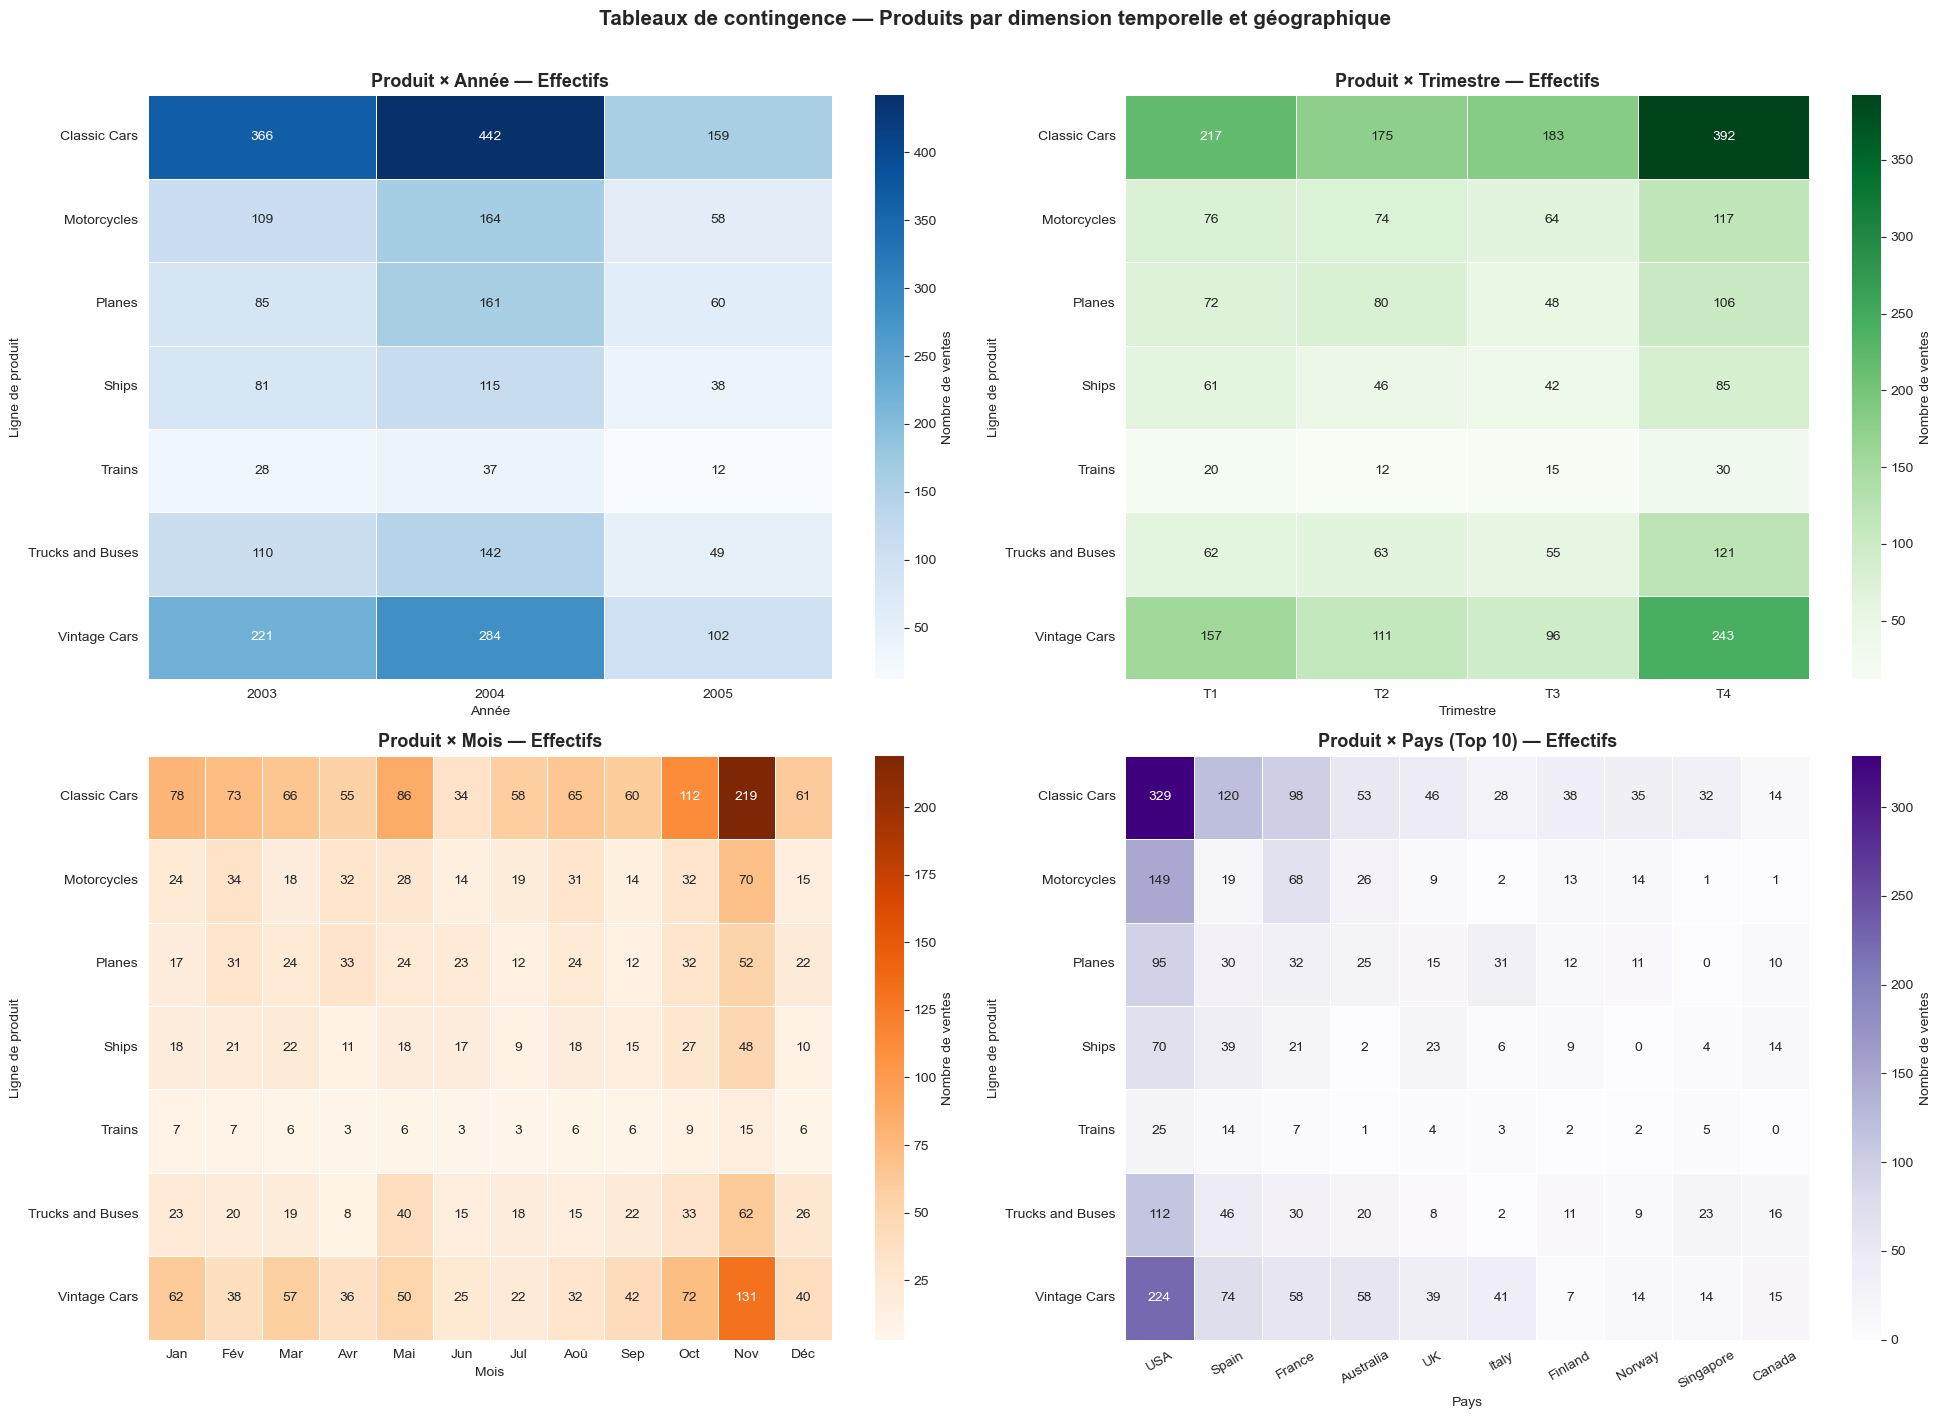

In [37]:
# ============================================================
# VISUALISATION DES 4 TABLEAUX DE CONTINGENCE (HEATMAPS)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# -- Heatmap Produit × Année --
data_annee = pd.crosstab(df['ligne_produit'], df['annee'])
sns.heatmap(data_annee, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0, 0],
            cbar_kws={'label': 'Nombre de ventes'})
axes[0, 0].set_title("Produit × Année — Effectifs", fontweight='bold', fontsize=13)
axes[0, 0].set_xlabel("Année")
axes[0, 0].set_ylabel("Ligne de produit")

# -- Heatmap Produit × Trimestre --
data_trim = pd.crosstab(df['ligne_produit'], df['trimestre'])
data_trim.columns = [f"T{c}" for c in data_trim.columns]
sns.heatmap(data_trim, annot=True, fmt='d', cmap='Greens',
            linewidths=0.5, ax=axes[0, 1],
            cbar_kws={'label': 'Nombre de ventes'})
axes[0, 1].set_title("Produit × Trimestre — Effectifs", fontweight='bold', fontsize=13)
axes[0, 1].set_xlabel("Trimestre")
axes[0, 1].set_ylabel("Ligne de produit")

# -- Heatmap Produit × Mois --
noms_mois = {1:"Jan",2:"Fév",3:"Mar",4:"Avr",5:"Mai",6:"Jun",
             7:"Jul",8:"Aoû",9:"Sep",10:"Oct",11:"Nov",12:"Déc"}
df['mois_nom'] = df['mois'].map(noms_mois)
data_mois = pd.crosstab(df['ligne_produit'], df['mois_nom'])
ordre = [m for m in noms_mois.values() if m in data_mois.columns]
data_mois = data_mois[ordre]
sns.heatmap(data_mois, annot=True, fmt='d', cmap='Oranges',
            linewidths=0.5, ax=axes[1, 0],
            cbar_kws={'label': 'Nombre de ventes'})
axes[1, 0].set_title("Produit × Mois — Effectifs", fontweight='bold', fontsize=13)
axes[1, 0].set_xlabel("Mois")
axes[1, 0].set_ylabel("Ligne de produit")
df.drop(columns=['mois_nom'], inplace=True)

# -- Heatmap Produit × Pays (Top 10 pays) --
data_pays = pd.crosstab(df['ligne_produit'], df['pays'])
top10_pays = data_pays.sum().sort_values(ascending=False).head(10).index
data_pays_top = data_pays[top10_pays]
sns.heatmap(data_pays_top, annot=True, fmt='d', cmap='Purples',
            linewidths=0.5, ax=axes[1, 1],
            cbar_kws={'label': 'Nombre de ventes'})
axes[1, 1].set_title("Produit × Pays (Top 10) — Effectifs", fontweight='bold', fontsize=13)
axes[1, 1].set_xlabel("Pays")
axes[1, 1].set_ylabel("Ligne de produit")
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle("Tableaux de contingence — Produits par dimension temporelle et géographique",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("heatmaps_contingence.png", dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# ============================================================
# EXPORT DES 4 TABLEAUX EN FICHIERS EXCEL SÉPARÉS
# ============================================================

# Dossier de sauvegarde (même que ton notebook)
dossier = r"C:\Users\Princesse\Downloads\Nouveau_départ\Entreprises\1\ "

# -- Fichier 1 : Produit × Année --
with pd.ExcelWriter(dossier + "produit_par_annee.xlsx", engine='openpyxl') as writer:
    contingence_annee.to_excel(writer,       sheet_name='Effectifs')
    contingence_annee_pct.to_excel(writer,   sheet_name='Pct_Total')
    contingence_annee_ligne.to_excel(writer, sheet_name='Pct_Par_Produit')
    contingence_annee_col.to_excel(writer,   sheet_name='Pct_Par_Annee')
print("✅ Fichier 1 créé : produit_par_annee.xlsx")

# -- Fichier 2 : Produit × Trimestre --
with pd.ExcelWriter(dossier + "produit_par_trimestre.xlsx", engine='openpyxl') as writer:
    contingence_trim.to_excel(writer,       sheet_name='Effectifs')
    contingence_trim_pct.to_excel(writer,   sheet_name='Pct_Total')
    contingence_trim_ligne.to_excel(writer, sheet_name='Pct_Par_Produit')
print("✅ Fichier 2 créé : produit_par_trimestre.xlsx")

# -- Fichier 3 : Produit × Mois --
with pd.ExcelWriter(dossier + "produit_par_mois.xlsx", engine='openpyxl') as writer:
    contingence_mois.to_excel(writer,       sheet_name='Effectifs')
    contingence_mois_pct.to_excel(writer,   sheet_name='Pct_Total')
    contingence_mois_ligne.to_excel(writer, sheet_name='Pct_Par_Produit')
print("✅ Fichier 3 créé : produit_par_mois.xlsx")

# -- Fichier 4 : Produit × Pays --
with pd.ExcelWriter(dossier + "produit_par_pays.xlsx", engine='openpyxl') as writer:
    contingence_pays.to_excel(writer,       sheet_name='Effectifs')
    contingence_pays_pct.to_excel(writer,   sheet_name='Pct_Total')
    contingence_pays_ligne.to_excel(writer, sheet_name='Pct_Par_Produit')
    contingence_pays_col.to_excel(writer,   sheet_name='Pct_Par_Pays')
print("✅ Fichier 4 créé : produit_par_pays.xlsx")

print("\n📁 Les 4 fichiers sont dans :", dossier)

✅ Fichier 1 créé : produit_par_annee.xlsx
✅ Fichier 2 créé : produit_par_trimestre.xlsx
✅ Fichier 3 créé : produit_par_mois.xlsx
✅ Fichier 4 créé : produit_par_pays.xlsx

📁 Les 4 fichiers sont dans : C:\Users\Princesse\Downloads\Nouveau_départ\Entreprises\1\ 
